# Lecture 9: Tests of the CAPM, Multifactor Models, Liquidity, and Asset-Pricing Puzzles

## Investment Analysis

This lecture studies how asset-pricing models are tested. The core CAPM question is simple:

> Do assets with higher exposure to systematic market risk earn higher expected returns?

The empirical answer is complicated. Expected returns are noisy, betas are estimated with error, the true market portfolio is unobservable, important non-traded assets are missing from stock indexes, risk premia vary through time, factors can be data-mined, liquidity matters, and the equity premium is difficult to explain in simple models.

The notebook includes simulations, two-pass Fama-MacBeth tests, Roll's critique, beta-measurement-error examples, Black-Jensen-Scholes beta-sorted portfolios, multifactor tests, JKP factor data, liquidity-beta examples, and the equity premium puzzle.

# 1. Learning Objectives

By the end of this lecture, students should be able to:

1. Explain the empirical predictions of the CAPM.
2. Run a two-pass Fama-MacBeth test.
3. Explain beta measurement error and attenuation bias.
4. Explain the Black-Jensen-Scholes portfolio-sorting remedy.
5. Explain Roll's critique and the unobservability of the true market portfolio.
6. Show with simulations why CAPM tests can fail even when the model is true.
7. Explain how non-traded assets alter the observed security market line.
8. Explain hedge-factor logic from intertemporal investment opportunities and consumption risks.
9. Test simple multifactor models.
10. Discuss Fama-French factors, the factor zoo, data mining, multiple testing, liquidity, and the equity premium puzzle.

# 2. Setup: Libraries and Data

The notebook uses simulations for conceptual clarity and the uploaded JKP all-factors file when available:

```text
[usa]_[all_factors]_[monthly]_[vw_cap].csv
```

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2040)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

JKP_FILE = Path('/mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap].csv')
if not JKP_FILE.exists():
    JKP_FILE = Path('[usa]_[all_factors]_[monthly]_[vw_cap].csv')

print('JKP file:', JKP_FILE)
print('Exists:', JKP_FILE.exists())

JKP file: /mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap].csv
Exists: True


In [2]:
if JKP_FILE.exists():
    jkp_long = pd.read_csv(JKP_FILE, encoding='utf-8-sig')
    jkp_long['date'] = pd.to_datetime(jkp_long['date'])
    jkp_factors = (
        jkp_long
        .pivot_table(index='date', columns='name', values='ret', aggfunc='mean')
        .sort_index()
    )
    jkp_factors.index.name = 'Date'
else:
    jkp_long = None
    jkp_factors = pd.DataFrame()

display(jkp_factors.head())
print('JKP factor matrix shape:', jkp_factors.shape)
print('First few factor names:', list(jkp_factors.columns[:10]))

name,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,at_me,at_turnover,be_gr1a,be_me,beta_60m,beta_dimson_21d,betabab_1260d,betadown_252d,bev_mev,bidaskhl_21d,capex_abn,capx_gr1,capx_gr2,capx_gr3,cash_at,chcsho_12m,coa_gr1a,col_gr1a,cop_at,cop_atl1,corr_1260d,coskew_21d,cowc_gr1a,dbnetis_at,debt_gr3,debt_me,dgp_dsale,div12m_me,dolvol_126d,dolvol_var_126d,dsale_dinv,dsale_drec,dsale_dsga,earnings_variability,...,ret_12_1,ret_12_7,ret_1_0,ret_3_1,ret_60_12,ret_6_1,ret_9_1,rmax1_21d,rmax5_21d,rmax5_rvol_21d,rskew_21d,rvol_21d,sale_bev,sale_emp_gr1,sale_gr1,sale_gr3,sale_me,saleq_gr1,saleq_su,seas_11_15an,seas_11_15na,seas_16_20an,seas_16_20na,seas_1_1an,seas_1_1na,seas_2_5an,seas_2_5na,seas_6_10an,seas_6_10na,sti_gr1a,taccruals_at,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1926-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-02-28,-0.0661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0185,NaN,NaN,NaN,-0.0312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0184,NaN,NaN,NaN,NaN,0.0360,0.0379,NaN,0.0108,0.0423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0204,NaN
1926-03-31,-0.0920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0581,NaN,NaN,NaN,-0.0630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0442,NaN,NaN,NaN,NaN,0.0373,0.0386,NaN,-0.0257,0.0604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0222,NaN
1926-04-30,-0.0183,NaN,NaN,-0.0036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0077,NaN,NaN,NaN,-0.0106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0088,NaN,NaN,NaN,NaN,NaN,NaN,-0.0089,0.0076,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,-0.0096,NaN,NaN,NaN,-0.0089,-0.0044,NaN,0.0040,-0.0022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0024,0.0055,NaN,-0.0034,-0.0045,NaN
1926-05-31,-0.0096,NaN,NaN,0.0055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,NaN,NaN,NaN,-0.0139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0036,NaN,NaN,NaN,NaN,NaN,NaN,0.0060,0.0034,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0224,0.0200,NaN,NaN,NaN,-0.0042,0.0039,NaN,-0.0078,0.0062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0069,0.0006,NaN,-0.0014,-0.0038,NaN


JKP factor matrix shape: (1200, 153)
First few factor names: ['age', 'aliq_at', 'aliq_mat', 'ami_126d', 'at_be', 'at_gr1', 'at_me', 'at_turnover', 'be_gr1a', 'be_me']


In [3]:
def ols(y, X, add_const=True):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if add_const:
        X = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    fitted = X @ beta
    resid = y - fitted
    n, k = X.shape
    s2 = resid @ resid / max(n-k, 1)
    cov_beta = s2 * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.maximum(np.diag(cov_beta), 0))
    t = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se>0)
    denom = ((y-y.mean()) @ (y-y.mean()))
    r2 = np.nan if denom == 0 else 1 - (resid @ resid) / denom
    return {'coef': beta, 'se': se, 't': t, 'resid': resid, 'fitted': fitted, 'r2': r2}

def annualized_summary(factors, periods_per_year=12):
    out = pd.DataFrame(index=factors.columns)
    out['Mean Ann. Return'] = factors.mean() * periods_per_year
    out['Ann. Volatility'] = factors.std(ddof=1) * np.sqrt(periods_per_year)
    out['Sharpe Ratio'] = out['Mean Ann. Return'] / out['Ann. Volatility']
    out['Skewness'] = factors.skew()
    out['Excess Kurtosis'] = factors.kurtosis()
    out['Worst Month'] = factors.min()
    out['Best Month'] = factors.max()
    out['Observations'] = factors.count()
    return out.sort_values('Sharpe Ratio', ascending=False)

def drawdown_from_returns(r):
    wealth = (1 + r.fillna(0)).cumprod()
    return wealth / wealth.cummax() - 1

# 3. What Does the CAPM Predict?

The CAPM predicts that expected excess returns are linear in market beta:

$$
\mathbb{E}[R_i]-R_f = \beta_i\left(\mathbb{E}[R_M]-R_f\right),
$$

where:

$$
\beta_i = \frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}.
$$

The security market line is:

$$
\mathbb{E}[R_i] = R_f + \beta_i\left(\mathbb{E}[R_M]-R_f\right).
$$

A cross-sectional test often estimates:

$$
\bar{R}_i - \bar{R}_f = \gamma_0 + \gamma_1\hat{\beta}_i + u_i.
$$

The CAPM predicts:

$$
\gamma_0=0,
\qquad
\gamma_1=\mathbb{E}[R_M]-R_f.
$$

# 4. Two-Pass Tests: Fama-MacBeth Regressions

The classic empirical procedure has two passes.

## First pass: estimate betas

For each asset:

$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\epsilon_{i,t}.
$$

## Second pass: estimate the cross-sectional price of risk

Each period:

$$
R_{i,t}-R_{f,t}=\gamma_{0,t}+\gamma_{1,t}\hat{\beta}_i+\eta_{i,t}.
$$

Then average the period-by-period estimates:

$$
\bar{\gamma}_1=\frac{1}{T}\sum_{t=1}^{T}\gamma_{1,t}.
$$

The standard error is computed from the time-series variation of the estimated \(\gamma_{1,t}\)'s.

# 5. Simulation: A CAPM World

We first simulate a world where the CAPM is true. True expected excess returns are:

$$
\mathbb{E}[R_i-R_f]=\beta_i\lambda_M.
$$

Then we estimate betas and run the two-pass test.

In [4]:
T, N = 240, 100
lambda_m, sigma_m = 0.006, 0.045
true_betas = np.linspace(0.4, 1.8, N)
sigma_eps = np.linspace(0.04, 0.09, N)

market_shock = np.random.normal(0, sigma_m, T)
market_excess = lambda_m + market_shock
asset_excess = np.zeros((T, N))
for i in range(N):
    asset_excess[:, i] = true_betas[i]*lambda_m + true_betas[i]*market_shock + np.random.normal(0, sigma_eps[i], T)
asset_excess_df = pd.DataFrame(asset_excess, columns=[f'Asset_{i+1:03d}' for i in range(N)])

beta_hat, alpha_hat = [], []
for col in asset_excess_df.columns:
    res = ols(asset_excess_df[col], market_excess)
    alpha_hat.append(res['coef'][0])
    beta_hat.append(res['coef'][1])
beta_hat = np.array(beta_hat)
alpha_hat = np.array(alpha_hat)

gammas = []
for t in range(T):
    res = ols(asset_excess_df.iloc[t].values, beta_hat)
    gammas.append(res['coef'])
gammas = pd.DataFrame(gammas, columns=['gamma_0','gamma_1'])

fm = pd.DataFrame({'Estimate': gammas.mean(), 'Std Error': gammas.std(ddof=1)/np.sqrt(T)})
fm['t-stat'] = fm['Estimate']/fm['Std Error']
display(fm)
print(f'True monthly market risk premium: {lambda_m:.4%}')

,Estimate,Std Error,t-stat
gamma_0,0.0014,0.0010,1.4256
gamma_1,0.0053,0.0032,1.6280


True monthly market risk premium: 0.6000%


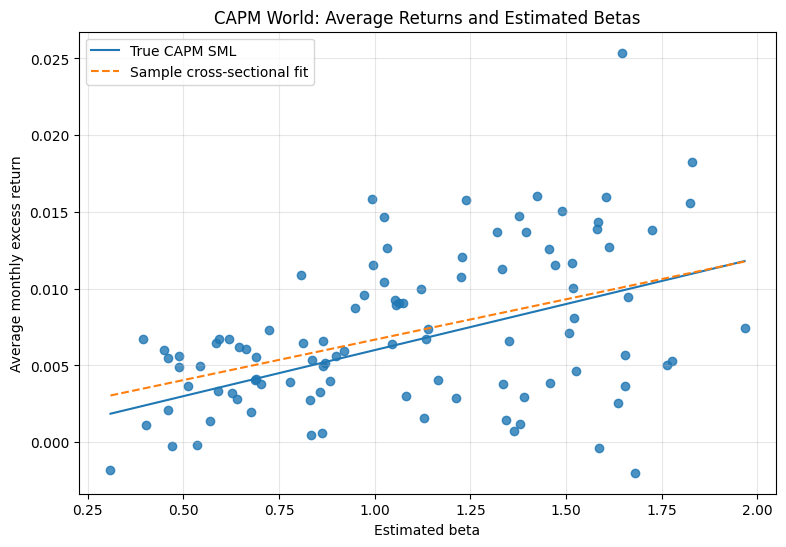

In [5]:
plt.figure(figsize=(9,6))
plt.scatter(beta_hat, asset_excess_df.mean(), alpha=0.8)
x = np.linspace(beta_hat.min(), beta_hat.max(), 100)
cs = ols(asset_excess_df.mean().values, beta_hat)
plt.plot(x, lambda_m*x, label='True CAPM SML')
plt.plot(x, cs['coef'][0]+cs['coef'][1]*x, linestyle='--', label='Sample cross-sectional fit')
plt.xlabel('Estimated beta')
plt.ylabel('Average monthly excess return')
plt.title('CAPM World: Average Returns and Estimated Betas')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# 6. Roll's Critique

Roll's critique says that the CAPM is a statement about the **true market portfolio** of all assets, not merely a stock index.

The true market portfolio should include public equities, bonds, private businesses, real estate, human capital, durable goods, and other wealth claims. Empirical tests usually use a stock-market proxy.

Therefore:

> A rejection of the CAPM using a market proxy may reject the proxy rather than the CAPM itself.

If the true market portfolio is mean-variance efficient, then the CAPM relation holds relative to it. But if we cannot observe that portfolio, the test is fundamentally problematic.

# 7. Simulation: CAPM True, Market Proxy Incomplete

We simulate a world where the CAPM is true relative to a true wealth portfolio, but the econometrician observes only an incomplete market proxy.

Slope on proxy beta: 0.9429%
t-stat: 9.86
Correlation true wealth beta vs proxy beta: 0.915


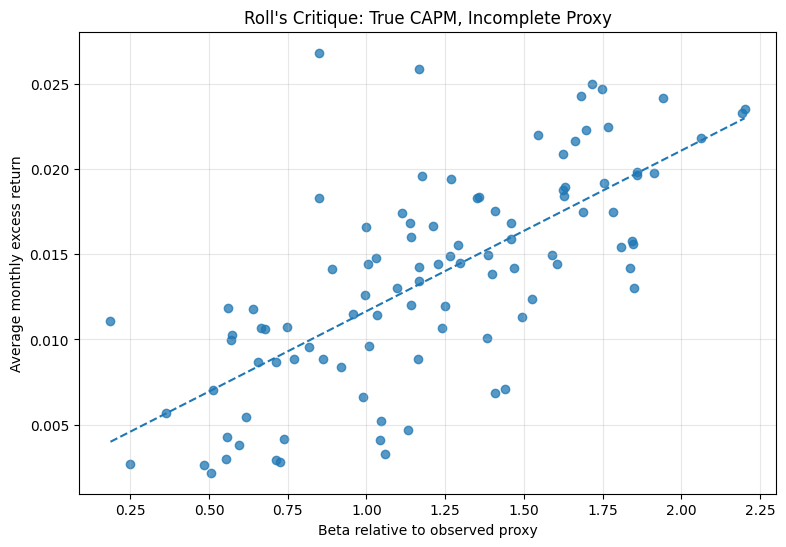

In [6]:
np.random.seed(2041)
T, N = 240, 100
lambda_w, sigma_w, sigma_missing = 0.006, 0.045, 0.04
wealth_shock = np.random.normal(0, sigma_w, T)
missing_shock = np.random.normal(0, sigma_missing, T)
proxy_market = lambda_w + 0.75*wealth_shock + 0.25*missing_shock + np.random.normal(0, 0.015, T)

beta_w = np.linspace(0.4, 1.8, N)
loading_missing = np.random.normal(0, 0.8, N)
R = np.zeros((T, N))
for i in range(N):
    R[:, i] = beta_w[i]*lambda_w + beta_w[i]*wealth_shock + loading_missing[i]*missing_shock + np.random.normal(0, 0.06, T)

proxy_betas = np.array([ols(R[:, i], proxy_market)['coef'][1] for i in range(N)])
cs_proxy = ols(R.mean(axis=0), proxy_betas)

print(f'Slope on proxy beta: {cs_proxy["coef"][1]:.4%}')
print(f't-stat: {cs_proxy["t"][1]:.2f}')
print(f'Correlation true wealth beta vs proxy beta: {np.corrcoef(beta_w, proxy_betas)[0,1]:.3f}')

plt.figure(figsize=(9,6))
plt.scatter(proxy_betas, R.mean(axis=0), alpha=0.75)
x = np.linspace(proxy_betas.min(), proxy_betas.max(), 100)
plt.plot(x, cs_proxy['coef'][0]+cs_proxy['coef'][1]*x, linestyle='--')
plt.xlabel('Beta relative to observed proxy')
plt.ylabel('Average monthly excess return')
plt.title("Roll's Critique: True CAPM, Incomplete Proxy")
plt.grid(True, alpha=0.3); plt.show()

# 8. Highly Diversified Portfolios Can Still Produce Weak CAPM Tests

Diversification reduces idiosyncratic noise, but it does not eliminate finite-sample uncertainty, beta estimation error, market-proxy error, or weak cross-sectional beta dispersion.

The next simulation repeats CAPM-true portfolio tests many times and records how often the beta slope is insignificant.

,Slope,t-stat
count,500.0000,500.0000
mean,0.0042,1.5961
std,0.0049,1.9216
min,-0.0108,-4.9917
25%,0.0008,0.2867
50%,0.0040,1.5099
75%,0.0074,2.8144
max,0.0197,8.5257


Fraction with insignificant beta slope: 0.558


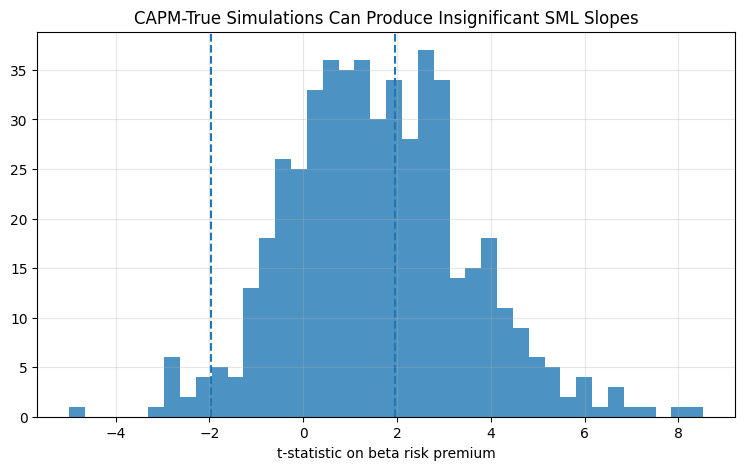

In [7]:
np.random.seed(2042)

def simulate_capm_portfolio_test(T=120, N_assets=200, N_portfolios=20, lambda_m=0.004, sigma_m=0.05, sigma_eps=0.10):
    b = np.random.uniform(0.6, 1.4, N_assets)
    mshock = np.random.normal(0, sigma_m, T)
    mkt = lambda_m + mshock
    R = np.zeros((T, N_assets))
    for i in range(N_assets):
        R[:, i] = b[i]*lambda_m + b[i]*mshock + np.random.normal(0, sigma_eps, T)
    groups = np.array_split(np.argsort(b), N_portfolios)
    port_R = np.column_stack([R[:, g].mean(axis=1) for g in groups])
    port_b = np.array([ols(port_R[:, j], mkt)['coef'][1] for j in range(N_portfolios)])
    cs = ols(port_R.mean(axis=0), port_b)
    return cs['coef'][1], cs['t'][1]

sim = pd.DataFrame([simulate_capm_portfolio_test() for _ in range(500)], columns=['Slope','t-stat'])
display(sim.describe())
print('Fraction with insignificant beta slope:', (sim['t-stat'].abs() < 1.96).mean())

plt.figure(figsize=(9,5))
plt.hist(sim['t-stat'], bins=40, alpha=0.8)
plt.axvline(1.96, linestyle='--'); plt.axvline(-1.96, linestyle='--')
plt.xlabel('t-statistic on beta risk premium')
plt.title('CAPM-True Simulations Can Produce Insignificant SML Slopes')
plt.grid(True, alpha=0.3); plt.show()

# 9. Measurement Error in Beta

Estimated beta is noisy. If:

$$
\hat{\beta}_i=\beta_i+\nu_i,
$$

and the second-pass regression uses \(\hat{\beta}_i\), the estimated slope is biased toward zero. This is attenuation bias.

In CAPM tests, beta measurement error makes the empirical SML too flat.

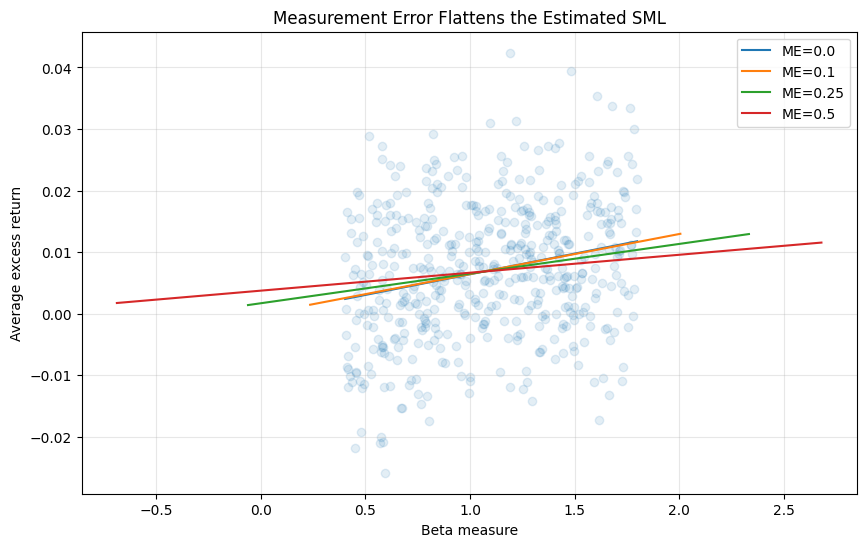

,Beta Measurement Error Std Dev,Estimated SML Slope,t-stat
0,0.0000,0.0067,5.5930
1,0.1000,0.0065,5.6311
2,0.2500,0.0048,4.8416
3,0.5000,0.0029,3.7380


True SML slope: 0.6000%


In [8]:
np.random.seed(2043)
N = 500
true_beta = np.random.uniform(0.4, 1.8, N)
true_lambda = 0.006
mean_ret = true_lambda*true_beta + np.random.normal(0, 0.010, N)
rows=[]
plt.figure(figsize=(10,6))
for me in [0.00, 0.10, 0.25, 0.50]:
    beta_meas = true_beta + np.random.normal(0, me, N)
    res = ols(mean_ret, beta_meas)
    rows.append({'Beta Measurement Error Std Dev':me, 'Estimated SML Slope':res['coef'][1], 't-stat':res['t'][1]})
    x = np.linspace(beta_meas.min(), beta_meas.max(), 100)
    plt.plot(x, res['coef'][0]+res['coef'][1]*x, label=f'ME={me}')
plt.scatter(true_beta, mean_ret, alpha=0.12)
plt.xlabel('Beta measure'); plt.ylabel('Average excess return')
plt.title('Measurement Error Flattens the Estimated SML')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
display(pd.DataFrame(rows))
print(f'True SML slope: {true_lambda:.4%}')

# 10. Black-Jensen-Scholes Methodology

Black, Jensen, and Scholes reduced beta measurement error by forming portfolios sorted on estimated beta.

The logic is:

1. Estimate individual betas in an initial period.
2. Sort stocks into beta portfolios.
3. Estimate portfolio betas and returns in a later period.
4. Test the SML using portfolios rather than individual securities.

Portfolios average out firm-specific noise and provide more precise beta estimates.

,Portfolio,Formation Beta Avg,Test Beta,Avg Excess Return
0,1,0.2975,0.4398,0.0063
1,2,0.5792,0.5632,0.0038
2,3,0.7522,0.7360,0.0012
3,4,0.9354,0.9190,0.0087
4,5,1.0752,1.0594,0.0052
5,6,1.2344,1.3793,0.0099
6,7,1.3861,1.3800,0.0088
7,8,1.5527,1.5264,0.0100
8,9,1.7389,1.7391,0.0105
9,10,1.9998,1.7615,0.0111


Portfolio SML slope: 0.5521%; t-stat=3.81


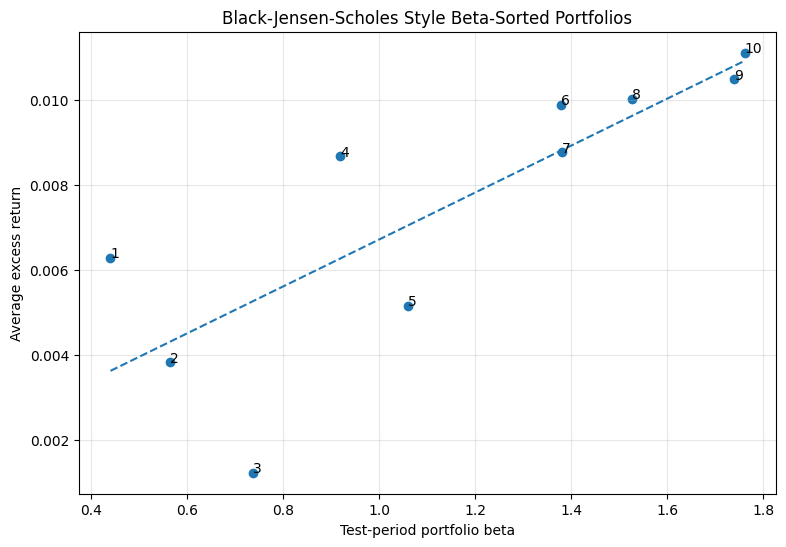

In [9]:
np.random.seed(2044)
T_est, T_test, N, P = 120, 120, 300, 10
lambda_m, sigma_m, sigma_eps = 0.006, 0.045, 0.10
true_beta = np.random.uniform(0.3, 2.0, N)

def sim_returns(T):
    shock = np.random.normal(0, sigma_m, T)
    mkt = lambda_m + shock
    R = np.column_stack([true_beta[i]*lambda_m + true_beta[i]*shock + np.random.normal(0, sigma_eps, T) for i in range(N)])
    return mkt, R

mkt_est, R_est = sim_returns(T_est)
mkt_test, R_test = sim_returns(T_test)
beta_form = np.array([ols(R_est[:, i], mkt_est)['coef'][1] for i in range(N)])
groups = np.array_split(np.argsort(beta_form), P)
port_R = np.column_stack([R_test[:, g].mean(axis=1) for g in groups])
port_b = np.array([ols(port_R[:, j], mkt_test)['coef'][1] for j in range(P)])
port_avg = port_R.mean(axis=0)
cs_bjs = ols(port_avg, port_b)

bjs = pd.DataFrame({'Portfolio':range(1,P+1), 'Formation Beta Avg':[beta_form[g].mean() for g in groups], 'Test Beta':port_b, 'Avg Excess Return':port_avg})
display(bjs)
print(f'Portfolio SML slope: {cs_bjs["coef"][1]:.4%}; t-stat={cs_bjs["t"][1]:.2f}')

plt.figure(figsize=(9,6))
plt.scatter(port_b, port_avg)
for _, r in bjs.iterrows(): plt.annotate(str(int(r['Portfolio'])), (r['Test Beta'], r['Avg Excess Return']))
x=np.linspace(port_b.min(), port_b.max(), 100)
plt.plot(x, cs_bjs['coef'][0]+cs_bjs['coef'][1]*x, linestyle='--')
plt.xlabel('Test-period portfolio beta'); plt.ylabel('Average excess return')
plt.title('Black-Jensen-Scholes Style Beta-Sorted Portfolios')
plt.grid(True, alpha=0.3); plt.show()

# 11. Tests of Multifactor Models

A multifactor model is:

$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_{i1}F_{1,t}+\cdots+\beta_{iK}F_{K,t}+\epsilon_{i,t}.
$$

The model predicts that alphas should be zero after accounting for factor exposures.

Time-series tests estimate alphas. Cross-sectional tests ask whether expected returns are explained by factor loadings.

# 12. Missing Assets and Non-Traded Wealth

The true market portfolio includes non-traded or imperfectly traded wealth such as labor income, private businesses, real estate, and human capital.

If these risks are priced, a stock-only SML can be distorted. For example, a stock that hedges labor-income risk may require a lower expected return than predicted by a stock-only CAPM.

Stock-only SML slope: 1.5301%; t-stat=13.60


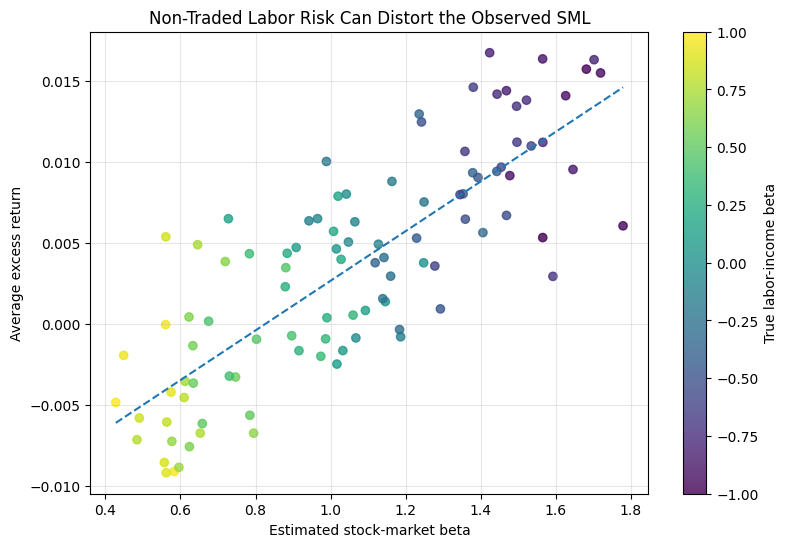

In [10]:
np.random.seed(2045)
N, T = 100, 240
stock_shock = np.random.normal(0, 0.045, T)
labor_shock = np.random.normal(0, 0.035, T)
lambda_stock, lambda_labor = 0.005, -0.003
beta_stock = np.linspace(0.5, 1.6, N)
beta_labor = np.linspace(1.0, -1.0, N)
R = np.zeros((T,N))
for i in range(N):
    expected = beta_stock[i]*lambda_stock + beta_labor[i]*lambda_labor
    R[:,i] = expected + beta_stock[i]*stock_shock + beta_labor[i]*labor_shock + np.random.normal(0,0.055,T)
stock_proxy = lambda_stock + stock_shock
b_hat = np.array([ols(R[:,i], stock_proxy)['coef'][1] for i in range(N)])
cs = ols(R.mean(axis=0), b_hat)
print(f'Stock-only SML slope: {cs["coef"][1]:.4%}; t-stat={cs["t"][1]:.2f}')
plt.figure(figsize=(9,6))
plt.scatter(b_hat, R.mean(axis=0), c=beta_labor, alpha=0.8)
plt.colorbar(label='True labor-income beta')
x=np.linspace(b_hat.min(), b_hat.max(),100)
plt.plot(x, cs['coef'][0]+cs['coef'][1]*x, linestyle='--')
plt.xlabel('Estimated stock-market beta'); plt.ylabel('Average excess return')
plt.title('Non-Traded Labor Risk Can Distort the Observed SML')
plt.grid(True, alpha=0.3); plt.show()

# 13. Hedge Factors and Intertemporal Asset Pricing

Merton's intertemporal CAPM emphasizes that investors care about future investment opportunities, not only next-period wealth.

Hedge factors may capture risks related to:

- interest rates,
- expected market risk premia,
- market volatility,
- inflation,
- labor income,
- liquidity,
- future consumption prices.

Assets that pay off when investment opportunities deteriorate can be valuable hedges and may earn lower expected returns.

In [11]:
np.random.seed(2046)
T, N = 240, 80
market_shock = np.random.normal(0, 0.045, T)
state_shock = np.random.normal(0, 0.030, T)
lambda_m, lambda_h = 0.005, -0.004
beta_m = np.random.uniform(0.6, 1.5, N)
beta_h = np.random.uniform(-1.0, 1.0, N)
R = np.zeros((T,N))
for i in range(N):
    exp = beta_m[i]*lambda_m + beta_h[i]*lambda_h
    R[:,i] = exp + beta_m[i]*market_shock + beta_h[i]*state_shock + np.random.normal(0,0.055,T)
one = ols(R.mean(axis=0), beta_m)
two = ols(R.mean(axis=0), np.column_stack([beta_m, beta_h]))
print('One-factor cross-section:', f'R2={one["r2"]:.3f}', f'market slope={one["coef"][1]:.4%}')
print('Two-factor cross-section:', f'R2={two["r2"]:.3f}', f'market slope={two["coef"][1]:.4%}', f'hedge slope={two["coef"][2]:.4%}')

One-factor cross-section: R2=0.009 market slope=0.1513%
Two-factor cross-section: R2=0.367 market slope=0.3873% hedge slope=-0.4917%


# 14. Fama-French Type Factor Models

The Fama-French three-factor model is:

$$
R_i-R_f=\alpha_i+\beta_{iM}(Mkt-RF)+\beta_{iS}SMB+\beta_{iH}HML+\epsilon_i.
$$

Size and book-to-market may be interpreted as risk factors, mispricing-related characteristics, or empirical summaries of common return patterns.

Later models add momentum, profitability, investment, quality, low-risk, and many other factors.

# 15. The Factor Zoo, P-Hacking, and Multiple Testing

The factor zoo refers to the large number of published return predictors.

Key problems include:

- p-hacking,
- data mining,
- data snooping,
- multiple testing,
- publication bias,
- post-publication decay,
- transaction costs and limited capacity.

If 1,000 fake factors are tested at the 5% level, around 50 may appear statistically significant by chance.

Fake factors tested: 1000
Number with |t| > 1.96: 51


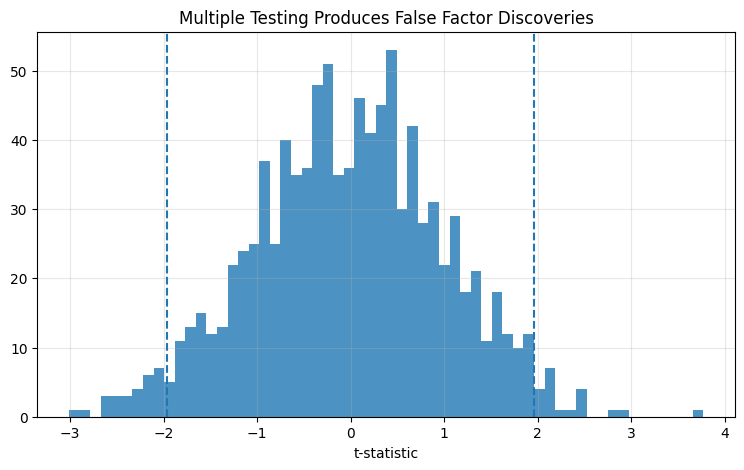

In [12]:
np.random.seed(2047)
T, K = 240, 1000
y = np.random.normal(0, 1, T)
tstats = np.array([ols(y, np.random.normal(0,1,T))['t'][1] for _ in range(K)])
print('Fake factors tested:', K)
print('Number with |t| > 1.96:', np.sum(np.abs(tstats)>1.96))
plt.figure(figsize=(9,5))
plt.hist(tstats, bins=60, alpha=0.8)
plt.axvline(1.96, linestyle='--'); plt.axvline(-1.96, linestyle='--')
plt.xlabel('t-statistic'); plt.title('Multiple Testing Produces False Factor Discoveries')
plt.grid(True, alpha=0.3); plt.show()

# 16. Using the JKP Factor Data

The uploaded JKP file provides a real-data view of a large set of factor portfolios. It is useful for discussing factor models, anomaly evidence, and data-mining caution.

In [13]:
if not jkp_factors.empty:
    jkp_summary = annualized_summary(jkp_factors)
    jkp_summary['Max Drawdown'] = jkp_factors.apply(drawdown_from_returns).min()
    display(jkp_summary.head(20))
    print('Number of factors:', jkp_factors.shape[1])
    print('Number with positive annualized mean:', (jkp_summary['Mean Ann. Return'] > 0).sum())
    print('Number with Sharpe ratio above 0.5:', (jkp_summary['Sharpe Ratio'] > 0.5).sum())
else:
    print('JKP data unavailable.')

,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Month,Best Month,Observations,Max Drawdown
name,,,,,,,,,
cop_at,0.0608,0.0578,1.0523,0.6473,3.3839,-0.0531,0.0957,890,-0.1194
noa_at,0.0520,0.0552,0.9430,0.2785,2.9521,-0.0639,0.1049,890,-0.2839
resff3_12_1,0.0684,0.0758,0.9019,-0.3492,6.3441,-0.1603,0.1170,872,-0.3340
nfna_gr1a,0.0297,0.0349,0.8524,0.0077,2.0610,-0.0436,0.0494,890,-0.1886
fnl_gr1a,0.0299,0.0355,0.8419,-0.0029,1.8307,-0.0436,0.0472,890,-0.2583
dsale_dinv,0.0334,0.0402,0.8314,-0.1200,2.3432,-0.0665,0.0575,878,-0.2831
nncoa_gr1a,0.0479,0.0577,0.8291,0.9134,6.7775,-0.0730,0.1177,890,-0.2178
cop_atl1,0.0510,0.0618,0.8255,0.3866,2.8798,-0.0741,0.0962,890,-0.1375
oaccruals_ni,0.0407,0.0493,0.8251,-0.0527,1.9797,-0.0746,0.0660,890,-0.1405


Number of factors: 153
Number with positive annualized mean: 135
Number with Sharpe ratio above 0.5: 37


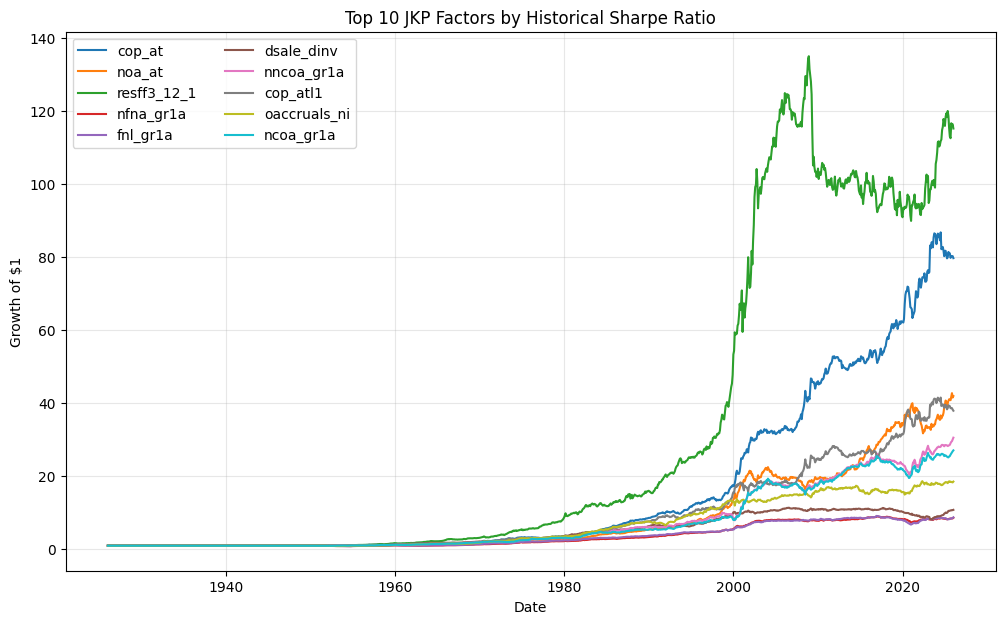

In [14]:
if not jkp_factors.empty:
    top10 = jkp_summary.head(10).index.tolist()
    wealth = (1 + jkp_factors[top10].fillna(0)).cumprod()
    plt.figure(figsize=(12,7))
    for col in wealth.columns:
        plt.plot(wealth.index, wealth[col], label=col)
    plt.xlabel('Date'); plt.ylabel('Growth of $1')
    plt.title('Top 10 JKP Factors by Historical Sharpe Ratio')
    plt.legend(ncol=2); plt.grid(True, alpha=0.3); plt.show()

# 17. Liquidity and Asset Pricing

Liquidity is valuable because investors care about the ability to trade quickly, cheaply, and in size.

Liquidity may be priced as:

1. a characteristic: illiquid assets require higher expected returns;
2. a systematic risk exposure: assets that become illiquid during marketwide liquidity crises require higher returns.

A simple liquidity-beta model is:

$$
\mathbb{E}[R_i]-R_f=\lambda_M\beta_{iM}+\lambda_L\beta_{iL}.
$$

Market-only R2: 0.006 slope: 0.1849%
Market + liquidity R2: 0.590 liq slope: 0.8871%


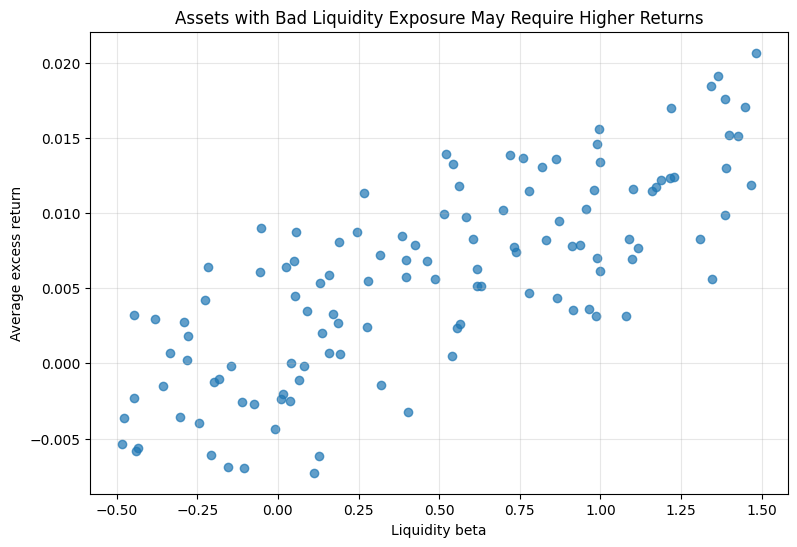

In [15]:
np.random.seed(2048)
T, N = 240, 120
market = np.random.normal(0,0.045,T)
liq = np.random.normal(0,0.030,T)
lambda_m, lambda_liq = 0.005, 0.004
beta_m = np.random.uniform(0.6,1.5,N)
beta_liq = np.random.uniform(-0.5,1.5,N)
R=np.zeros((T,N))
for i in range(N):
    exp = beta_m[i]*lambda_m + beta_liq[i]*lambda_liq
    R[:,i]=exp+beta_m[i]*market+beta_liq[i]*liq+np.random.normal(0,0.06,T)
one=ols(R.mean(axis=0), beta_m)
two=ols(R.mean(axis=0), np.column_stack([beta_m,beta_liq]))
print('Market-only R2:', f'{one["r2"]:.3f}', 'slope:', f'{one["coef"][1]:.4%}')
print('Market + liquidity R2:', f'{two["r2"]:.3f}', 'liq slope:', f'{two["coef"][2]:.4%}')
plt.figure(figsize=(9,6))
plt.scatter(beta_liq, R.mean(axis=0), alpha=0.7)
plt.xlabel('Liquidity beta'); plt.ylabel('Average excess return')
plt.title('Assets with Bad Liquidity Exposure May Require Higher Returns')
plt.grid(True, alpha=0.3); plt.show()

# 18. The Equity Premium Puzzle

The equity premium puzzle is the difficulty of explaining the large historical equity premium using simple consumption-based models.

With power utility, the stochastic discount factor is:

$$
M_{t+1}=\beta\left(\frac{C_{t+1}}{C_t}\right)^{-\gamma}.
$$

In a simple approximation:

$$
\mathbb{E}[R_i-R_f]\approx \gamma\operatorname{Cov}(R_i,\Delta c).
$$

Aggregate consumption growth is too smooth to explain the historical equity premium unless risk aversion is implausibly high.

In [16]:
equity_premium = 0.06
cons_vol = 0.02
eq_vol = 0.18
corr = 0.25
cov_eq_cons = cons_vol * eq_vol * corr
implied_gamma = equity_premium / cov_eq_cons
print(f'Assumed annual equity premium: {equity_premium:.2%}')
print(f'Assumed covariance with consumption growth: {cov_eq_cons:.4%}')
print(f'Implied risk aversion gamma: {implied_gamma:.2f}')

Assumed annual equity premium: 6.00%
Assumed covariance with consumption growth: 0.0900%
Implied risk aversion gamma: 66.67


# 19. Final Takeaways

1. Fama-MacBeth tests estimate factor risk premia using repeated cross-sectional regressions.
2. Roll's critique says CAPM tests require the true market portfolio, which is unobservable.
3. Even when the CAPM is true, finite samples and market-proxy problems can produce weak evidence.
4. Beta measurement error flattens the estimated SML.
5. Black-Jensen-Scholes beta-sorted portfolios reduce idiosyncratic noise and beta measurement error.
6. Multifactor models allow several systematic risks to be priced.
7. Missing assets such as labor income and private businesses can alter the observed SML.
8. Hedge factors can arise from interest rates, volatility, inflation, liquidity, labor income, and consumption-category risks.
9. Fama-French factors can be interpreted as risk factors, anomaly portfolios, or empirical summaries.
10. The factor zoo requires caution about p-hacking, data mining, and multiple testing.
11. Liquidity can be priced as a characteristic and as systematic liquidity beta.
12. The equity premium puzzle shows that simple consumption models struggle to explain the large historical equity premium.